<a href="https://colab.research.google.com/github/smshozab/AG-AquaSense/blob/main/AAIn4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Overview

This notebook implements the **environmental-disease correlation model** using XGBoost.

### What this notebook does
- Uses 10D sensor feature vector from Notebook 1
- Generates synthetic disease labels based on sensor conditions
- Trains XGBoost classifier
- Outputs:

  P_sensor → disease probability based on water quality

### Key outputs
- Model performance:
  - Accuracy, Macro F1
- Feature importance (XGBoost)
- SHAP analysis (feature impact)
- Predictions file: `p_sensor_predictions.csv`

### Usage
- Output probabilities are used in Notebook 5 (fusion)

### Note
- Labels are synthetic (prototype stage)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier
import shap

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_PATH = Path("/content/drive/MyDrive/aquasense/notebook1_outputs/sensor_feature_vector_10d.csv")
OUTPUT_DIR = Path("/content/drive/MyDrive/aquasense/notebook4_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DISEASE_CLASSES = [
    "Bacterial Red Disease",
    "Aeromoniasis",
    "Bacterial Gill Disease",
    "Saprolegniasis",
    "Healthy Fish",
    "Parasitic Diseases",
    "White Tail Disease"
]

FEATURE_COLUMNS = [
    "do", "ph", "temp", "tan", "turbidity",
    "a_do", "a_ph", "a_temp", "a_tan", "a_turb"
]

In [ ]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find feature file at {DATA_PATH.resolve()}. "
        "Make sure Notebook 1 ran successfully and saved sensor_feature_vector_10d.csv"
    )

feature_df = pd.read_csv(DATA_PATH)

print("Loaded feature data shape:", feature_df.shape)
display(feature_df.head())
print("Columns:", list(feature_df.columns))

Loaded feature data shape: (20160, 13)


,timestamp,tank_id,do,ph,temp,tan,turbidity,a_do,a_ph,a_temp,a_tan,a_turbidity,any_anomaly_flag
0,2025-01-01 00:00:00,tank_1,7.007366,7.511361,27.155445,0.350220,9.099069,0.0,0.0,0.0,0.0,0.0,0
1,2025-01-01 00:01:00,tank_1,7.018486,7.510569,27.180153,0.349622,9.166870,0.0,0.0,0.0,0.0,0.0,0
2,2025-01-01 00:02:00,tank_1,7.007366,7.509776,27.204861,0.349024,9.234671,0.0,0.0,0.0,0.0,0.0,0
3,2025-01-01 00:03:00,tank_1,6.933231,7.491881,27.204861,0.333364,9.370712,0.0,0.0,0.0,0.0,0.0,0
4,2025-01-01 00:04:00,tank_1,7.029606,7.497093,27.219940,0.333364,9.453299,0.0,0.0,0.0,0.0,0.0,0


Columns: ['timestamp', 'tank_id', 'do', 'ph', 'temp', 'tan', 'turbidity', 'a_do', 'a_ph', 'a_temp', 'a_tan', 'a_turbidity', 'any_anomaly_flag']


In [ ]:
if "a_turbidity" in feature_df.columns and "a_turb" not in feature_df.columns:
    feature_df = feature_df.rename(columns={"a_turbidity": "a_turb"})

required_cols = ["timestamp", "tank_id"] + FEATURE_COLUMNS + ["any_anomaly_flag"]
missing_cols = [c for c in required_cols if c not in feature_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("All required columns are present.")
display(feature_df[required_cols].head())

All required columns are present.


,timestamp,tank_id,do,ph,temp,tan,turbidity,a_do,a_ph,a_temp,a_tan,a_turb,any_anomaly_flag
0,2025-01-01 00:00:00,tank_1,7.007366,7.511361,27.155445,0.350220,9.099069,0.0,0.0,0.0,0.0,0.0,0
1,2025-01-01 00:01:00,tank_1,7.018486,7.510569,27.180153,0.349622,9.166870,0.0,0.0,0.0,0.0,0.0,0
2,2025-01-01 00:02:00,tank_1,7.007366,7.509776,27.204861,0.349024,9.234671,0.0,0.0,0.0,0.0,0.0,0
3,2025-01-01 00:03:00,tank_1,6.933231,7.491881,27.204861,0.333364,9.370712,0.0,0.0,0.0,0.0,0.0,0
4,2025-01-01 00:04:00,tank_1,7.029606,7.497093,27.219940,0.333364,9.453299,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
display(feature_df[FEATURE_COLUMNS].describe().T)

,count,mean,std,min,25%,50%,75%,max
do,20160.0,6.534625,0.407982,5.411222,6.201839,6.508959,6.891832,7.419225
ph,20160.0,7.399706,0.086424,7.230785,7.316668,7.399340,7.482609,7.576874
temp,20160.0,27.539572,0.612203,26.535921,26.930385,27.535989,28.116937,29.255598
tan,20160.0,0.389400,0.088283,0.226967,0.334514,0.377282,0.422876,0.769278
turbidity,20160.0,9.734120,1.168821,7.439496,8.839052,9.612897,10.442728,13.895621
a_do,20160.0,-0.081280,1.088575,-3.467060,-1.042077,-0.108267,0.916923,2.434816
a_ph,20160.0,-0.059311,1.035170,-3.061702,-1.016997,-0.080477,0.924091,3.222005
a_temp,20160.0,-0.013501,1.050344,-2.379232,-1.044205,-0.014736,0.983889,2.303386
a_tan,20160.0,0.070281,1.181599,-3.529159,-0.755232,-0.168613,0.814256,8.720392
a_turb,20160.0,0.011051,1.095043,-3.055612,-0.895269,-0.122818,0.879586,3.338999


In [ ]:
def assign_synthetic_disease_label(row):
    do = row["do"]
    ph = row["ph"]
    temp = row["temp"]
    tan = row["tan"]
    turb = row["turbidity"]

    a_do = row["a_do"]
    a_ph = row["a_ph"]
    a_temp = row["a_temp"]
    a_tan = row["a_tan"]
    a_turb = row["a_turb"]

    score = {
        "Bacterial Red Disease": 0.0,
        "Aeromoniasis": 0.0,
        "Bacterial Gill Disease": 0.0,
        "Saprolegniasis": 0.0,
        "Healthy Fish": 0.0,
        "Parasitic Diseases": 0.0,
        "White Tail Disease": 0.0
    }

    # Healthy profile
    if (
        6.0 <= do <= 7.8 and
        7.1 <= ph <= 7.7 and
        26.5 <= temp <= 28.7 and
        tan <= 0.38 and
        turb <= 11.5 and
        abs(a_do) < 1.5 and
        abs(a_ph) < 1.5 and
        abs(a_temp) < 1.5 and
        abs(a_tan) < 1.5 and
        abs(a_turb) < 1.5
    ):
        score["Healthy Fish"] += 6.0

    # Bacterial Gill Disease
    if do < 5.9:
        score["Bacterial Gill Disease"] += 2.5
    if a_do < -2.0:
        score["Bacterial Gill Disease"] += 2.8
    if tan > 0.50:
        score["Bacterial Gill Disease"] += 2.2
    if a_tan > 2.0:
        score["Bacterial Gill Disease"] += 3.2
    if temp > 28.0:
        score["Bacterial Gill Disease"] += 0.7

    # Aeromoniasis
    if tan > 0.48:
        score["Aeromoniasis"] += 2.5
    if a_tan > 1.8:
        score["Aeromoniasis"] += 3.0
    if temp > 28.2:
        score["Aeromoniasis"] += 1.5
    if a_temp > 1.5:
        score["Aeromoniasis"] += 1.4
    if do < 6.0:
        score["Aeromoniasis"] += 0.8

    # Bacterial Red Disease
    if do < 6.0:
        score["Bacterial Red Disease"] += 1.6
    if a_do < -1.8:
        score["Bacterial Red Disease"] += 2.0
    if turb > 11.2:
        score["Bacterial Red Disease"] += 1.4
    if a_turb > 1.7:
        score["Bacterial Red Disease"] += 1.8
    if abs(a_ph) > 1.8:
        score["Bacterial Red Disease"] += 1.0
    if tan > 0.42:
        score["Bacterial Red Disease"] += 0.8

    # Saprolegniasis
    if temp < 27.0:
        score["Saprolegniasis"] += 1.8
    if a_temp < -1.5:
        score["Saprolegniasis"] += 1.5
    if turb > 10.5:
        score["Saprolegniasis"] += 1.2
    if abs(a_ph) > 1.5:
        score["Saprolegniasis"] += 1.3
    if do < 6.1:
        score["Saprolegniasis"] += 0.8

    # Parasitic Diseases
    if turb > 12.0:
        score["Parasitic Diseases"] += 2.8
    if a_turb > 2.0:
        score["Parasitic Diseases"] += 3.2
    if abs(a_ph) > 1.7:
        score["Parasitic Diseases"] += 1.2
    if do < 6.2:
        score["Parasitic Diseases"] += 0.7

    # White Tail Disease
    if temp > 28.6:
        score["White Tail Disease"] += 2.0
    if a_temp > 1.8:
        score["White Tail Disease"] += 2.2
    if turb > 11.0:
        score["White Tail Disease"] += 1.3
    if tan > 0.44:
        score["White Tail Disease"] += 1.2
    if a_tan > 1.4:
        score["White Tail Disease"] += 1.5

    # Healthy fallback boost when conditions are fairly stable
    if (
        do >= 6.1 and tan <= 0.40 and turb <= 11.0 and
        abs(a_do) < 1.3 and abs(a_tan) < 1.3 and abs(a_turb) < 1.3
    ):
        score["Healthy Fish"] += 2.5

    # Add tiny random jitter to avoid too many ties
    for k in score:
        score[k] += np.random.uniform(0, 0.15)

    label = max(score, key=score.get)
    return label

In [ ]:
feature_df["disease_label"] = feature_df.apply(assign_synthetic_disease_label, axis=1)

print("Synthetic labels created.")
display(feature_df[["timestamp", "tank_id"] + FEATURE_COLUMNS + ["disease_label"]].head())

Synthetic labels created.


,timestamp,tank_id,do,ph,temp,tan,turbidity,a_do,a_ph,a_temp,a_tan,a_turb,disease_label
0,2025-01-01 00:00:00,tank_1,7.007366,7.511361,27.155445,0.350220,9.099069,0.0,0.0,0.0,0.0,0.0,Healthy Fish
1,2025-01-01 00:01:00,tank_1,7.018486,7.510569,27.180153,0.349622,9.166870,0.0,0.0,0.0,0.0,0.0,Healthy Fish
2,2025-01-01 00:02:00,tank_1,7.007366,7.509776,27.204861,0.349024,9.234671,0.0,0.0,0.0,0.0,0.0,Healthy Fish
3,2025-01-01 00:03:00,tank_1,6.933231,7.491881,27.204861,0.333364,9.370712,0.0,0.0,0.0,0.0,0.0,Healthy Fish
4,2025-01-01 00:04:00,tank_1,7.029606,7.497093,27.219940,0.333364,9.453299,0.0,0.0,0.0,0.0,0.0,Healthy Fish


,count
disease_label,
Aeromoniasis,2544
Bacterial Gill Disease,911
Bacterial Red Disease,923
Healthy Fish,8931
Parasitic Diseases,315
Saprolegniasis,4345
White Tail Disease,2191


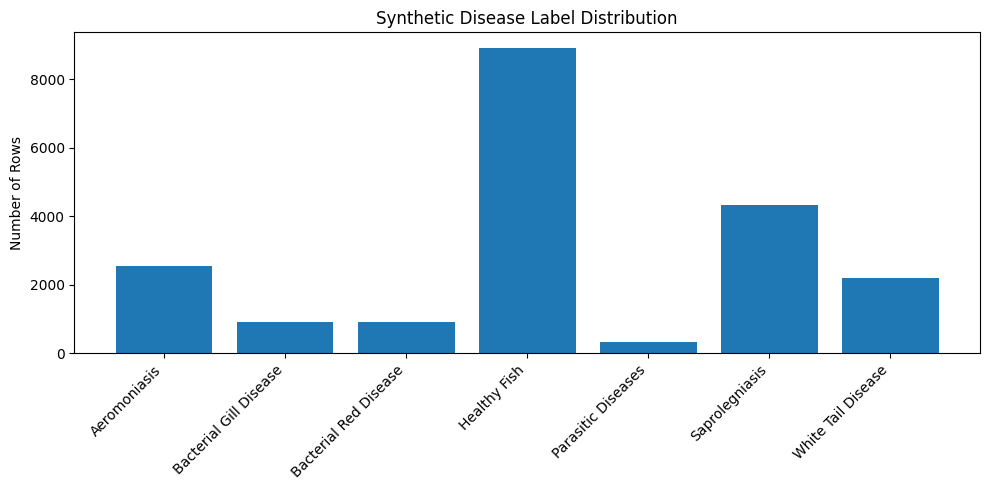

In [ ]:
label_counts = feature_df["disease_label"].value_counts().sort_index()
display(label_counts)

plt.figure(figsize=(10, 5))
plt.bar(label_counts.index, label_counts.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Rows")
plt.title("Synthetic Disease Label Distribution")
plt.tight_layout()
plt.show()

In [ ]:
min_class_size = feature_df["disease_label"].value_counts().min()
target_per_class = min(min_class_size, 1800)

balanced_parts = []
for cls in DISEASE_CLASSES:
    cls_df = feature_df[feature_df["disease_label"] == cls].copy()
    if len(cls_df) >= target_per_class:
        cls_df = cls_df.sample(target_per_class, random_state=SEED)
    balanced_parts.append(cls_df)

balanced_df = pd.concat(balanced_parts, axis=0).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Balanced dataset shape:", balanced_df.shape)
display(balanced_df["disease_label"].value_counts().sort_index())

Balanced dataset shape: (2205, 14)


,count
disease_label,
Aeromoniasis,315
Bacterial Gill Disease,315
Bacterial Red Disease,315
Healthy Fish,315
Parasitic Diseases,315
Saprolegniasis,315
White Tail Disease,315


In [ ]:
X = balanced_df[FEATURE_COLUMNS].copy()
y = balanced_df["disease_label"].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:", list(label_encoder.classes_))
print("X shape:", X.shape)
print("y shape:", y_encoded.shape)

Encoded classes: ['Aeromoniasis', 'Bacterial Gill Disease', 'Bacterial Red Disease', 'Healthy Fish', 'Parasitic Diseases', 'Saprolegniasis', 'White Tail Disease']
X shape: (2205, 10)
y shape: (2205,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (1764, 10) (1764,)
Test shape: (441, 10) (441,)


In [ ]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    n_estimators=250,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost training complete.")

XGBoost training complete.


In [ ]:
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)

print("Predictions shape:", y_pred.shape)
print("Probability matrix shape:", y_proba.shape)

proba_df = pd.DataFrame(y_proba, columns=[f"P_sensor_{cls}" for cls in label_encoder.classes_])
display(proba_df.head())

Predictions shape: (441,)
Probability matrix shape: (441, 7)


,P_sensor_Aeromoniasis,P_sensor_Bacterial Gill Disease,P_sensor_Bacterial Red Disease,P_sensor_Healthy Fish,P_sensor_Parasitic Diseases,P_sensor_Saprolegniasis,P_sensor_White Tail Disease
0,0.133466,0.001808,0.003089,0.000310,0.743283,0.000855,0.117189
1,0.000011,0.002484,0.000105,0.997311,0.000046,0.000028,0.000017
2,0.000009,0.000095,0.000166,0.999449,0.000216,0.000035,0.000030
3,0.000161,0.006812,0.969047,0.000085,0.001876,0.021346,0.000673
4,0.000397,0.004009,0.985624,0.000091,0.000360,0.007755,0.001763


In [ ]:
test_accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Macro F1:      {macro_f1:.4f}")
print(f"Weighted F1:   {weighted_f1:.4f}")

Test Accuracy: 0.9002
Macro F1:      0.9007
Weighted F1:   0.9007


In [ ]:
report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)

report_df = pd.DataFrame(report).T
display(report_df)

,precision,recall,f1-score,support
Aeromoniasis,0.982759,0.904762,0.942149,63.000000
Bacterial Gill Disease,0.830986,0.936508,0.880597,63.000000
Bacterial Red Disease,0.931034,0.857143,0.892562,63.000000
Healthy Fish,0.918033,0.888889,0.903226,63.000000
Parasitic Diseases,0.835821,0.888889,0.861538,63.000000
Saprolegniasis,0.887097,0.873016,0.880000,63.000000
White Tail Disease,0.937500,0.952381,0.944882,63.000000
accuracy,0.900227,0.900227,0.900227,0.900227
macro avg,0.903318,0.900227,0.900708,441.000000
weighted avg,0.903318,0.900227,0.900708,441.000000


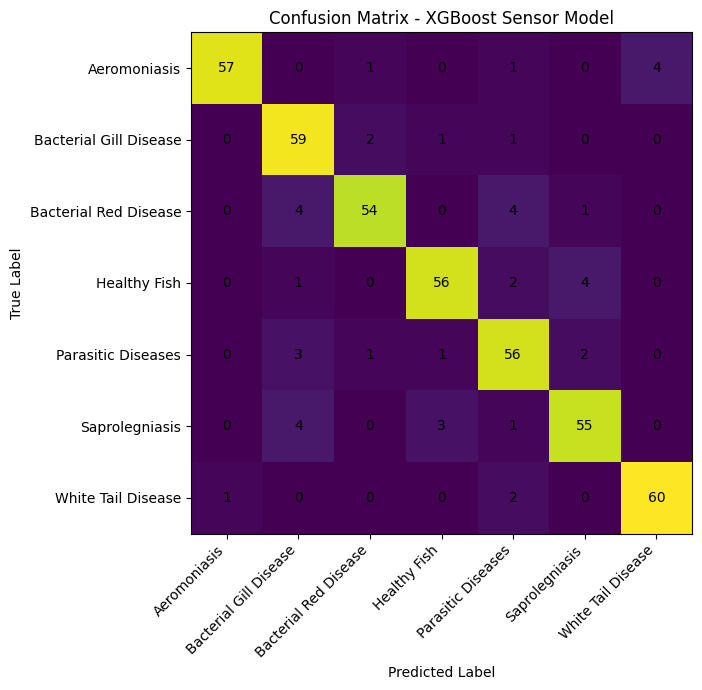

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm)

ax.set_xticks(np.arange(len(label_encoder.classes_)))
ax.set_yticks(np.arange(len(label_encoder.classes_)))
ax.set_xticklabels(label_encoder.classes_, rotation=45, ha="right")
ax.set_yticklabels(label_encoder.classes_)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix - XGBoost Sensor Model")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

,feature,importance
2,temp,0.197659
3,tan,0.136722
0,do,0.123364
5,a_do,0.122908
8,a_tan,0.117629
9,a_turb,0.078304
7,a_temp,0.075043
4,turbidity,0.069279
1,ph,0.041033
6,a_ph,0.038060


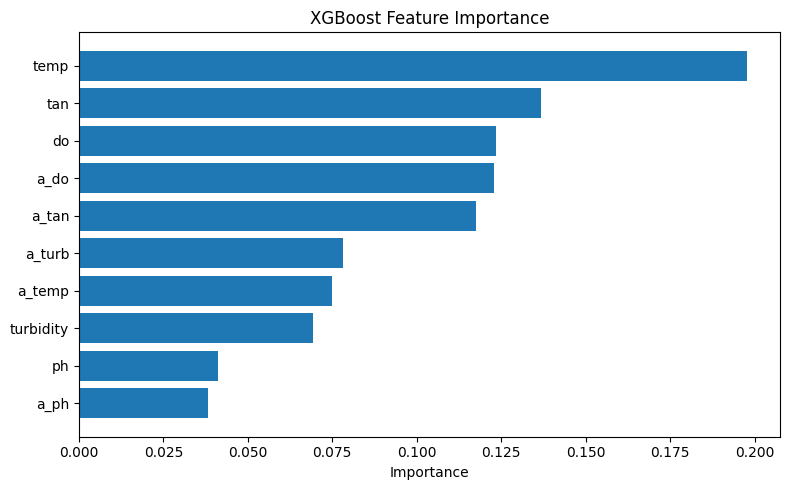

In [ ]:
importances = xgb_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": importances
}).sort_values("importance", ascending=False)

display(importance_df)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print("SHAP computation complete.")

SHAP computation complete.


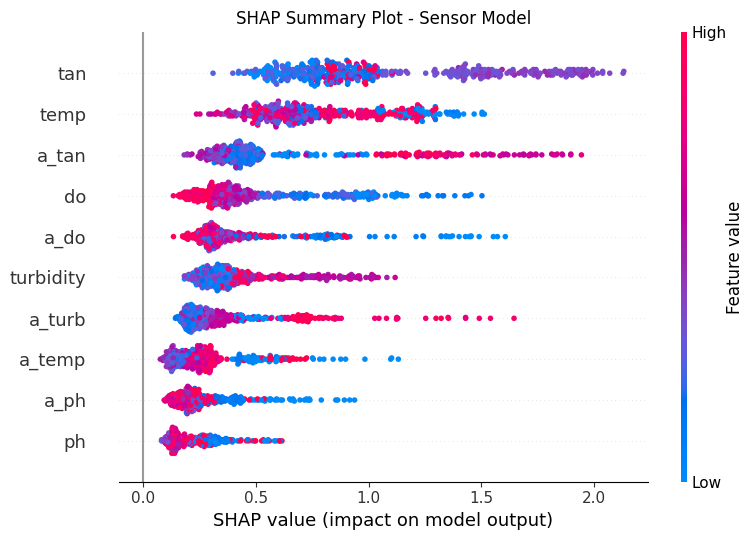

In [ ]:
# Handle different SHAP output formats
if isinstance(shap_values, list):
    # Old multiclass style: list of arrays, one per class
    shap_for_summary = np.mean(np.abs(np.stack(shap_values, axis=0)), axis=0)
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # New multiclass style: (n_samples, n_features, n_classes) or similar
    # Convert to (n_samples, n_features) via mean absolute SHAP across classes
    shap_for_summary = np.mean(np.abs(shap_values), axis=2)
else:
    shap_for_summary = shap_values

shap.summary_plot(shap_for_summary, X_test, show=False)
plt.title("SHAP Summary Plot - Sensor Model")
plt.tight_layout()
plt.show()

,feature,mean_abs_shap
3,tan,1.084885
2,temp,0.804669
8,a_tan,0.661673
0,do,0.523324
5,a_do,0.446721
4,turbidity,0.438592
9,a_turb,0.387595
7,a_temp,0.291016
6,a_ph,0.272354
1,ph,0.225819


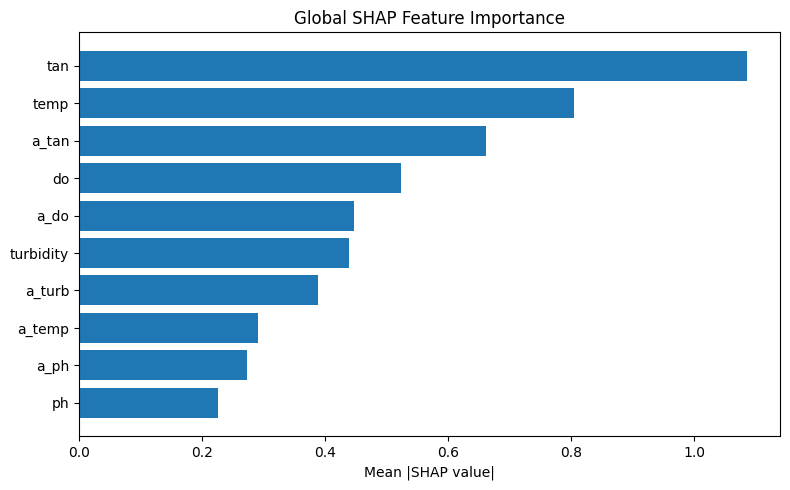

In [ ]:
if shap_for_summary.ndim != 2:
    raise ValueError(f"Unexpected SHAP summary shape: {shap_for_summary.shape}")

mean_abs_shap = np.abs(shap_for_summary).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance_df)

plt.figure(figsize=(8, 5))
plt.barh(shap_importance_df["feature"], shap_importance_df["mean_abs_shap"])
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP value|")
plt.title("Global SHAP Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
all_proba = xgb_model.predict_proba(balanced_df[FEATURE_COLUMNS])
all_pred = xgb_model.predict(balanced_df[FEATURE_COLUMNS])

pred_labels = label_encoder.inverse_transform(all_pred)

p_sensor_df = balanced_df[["timestamp", "tank_id"] + FEATURE_COLUMNS + ["disease_label"]].copy()
p_sensor_df["sensor_pred_label"] = pred_labels

for i, cls in enumerate(label_encoder.classes_):
    p_sensor_df[f"P_sensor_{cls}"] = all_proba[:, i]

display(p_sensor_df.head())

,timestamp,tank_id,do,ph,temp,tan,turbidity,a_do,a_ph,a_temp,...,a_turb,disease_label,sensor_pred_label,P_sensor_Aeromoniasis,P_sensor_Bacterial Gill Disease,P_sensor_Bacterial Red Disease,P_sensor_Healthy Fish,P_sensor_Parasitic Diseases,P_sensor_Saprolegniasis,P_sensor_White Tail Disease
0,2025-01-13 01:31:00,tank_1,6.808621,7.486847,27.449030,0.465207,10.429919,1.344428,1.009459,-0.220508,...,0.062595,White Tail Disease,White Tail Disease,0.003975,0.001033,0.009600,0.000373,0.003276,0.004669,0.977075
1,2025-01-11 18:58:00,tank_1,6.059563,7.363987,26.667226,0.388589,8.967176,-1.243605,-0.399945,-1.475268,...,-1.071868,Saprolegniasis,Saprolegniasis,0.000038,0.000063,0.000043,0.002044,0.000167,0.997610,0.000035
2,2025-01-05 09:15:00,tank_1,6.964514,7.401811,28.224975,0.342951,9.833359,0.784121,0.011361,1.283974,...,0.535652,Healthy Fish,Healthy Fish,0.006801,0.000425,0.000193,0.992414,0.000093,0.000028,0.000045
3,2025-01-08 04:15:00,tank_1,5.835228,7.501221,28.845101,0.679509,13.148290,-1.224627,1.160706,1.724881,...,2.091577,Aeromoniasis,Aeromoniasis,0.993668,0.004339,0.000225,0.000018,0.001407,0.000045,0.000297
4,2025-01-14 14:18:00,tank_1,6.105284,7.277716,27.294417,0.389847,9.364911,-0.906522,-1.417915,-0.364121,...,-0.833801,Parasitic Diseases,Parasitic Diseases,0.000061,0.000962,0.000728,0.002652,0.991236,0.004171,0.000191


In [ ]:
classification_report_path = OUTPUT_DIR / "xgboost_classification_report.csv"
feature_importance_path = OUTPUT_DIR / "xgboost_feature_importance.csv"
shap_importance_path = OUTPUT_DIR / "xgboost_shap_importance.csv"
p_sensor_path = OUTPUT_DIR / "p_sensor_predictions.csv"
balanced_data_path = OUTPUT_DIR / "sensor_balanced_labeled_dataset.csv"
metrics_path = OUTPUT_DIR / "xgboost_metrics_summary.csv"

report_df.to_csv(classification_report_path, index=True)
importance_df.to_csv(feature_importance_path, index=False)
shap_importance_df.to_csv(shap_importance_path, index=False)
p_sensor_df.to_csv(p_sensor_path, index=False)
balanced_df.to_csv(balanced_data_path, index=False)

metrics_df = pd.DataFrame({
    "metric": ["test_accuracy", "macro_f1", "weighted_f1"],
    "value": [test_accuracy, macro_f1, weighted_f1]
})
metrics_df.to_csv(metrics_path, index=False)

print("Saved files:")
print(classification_report_path.resolve())
print(feature_importance_path.resolve())
print(shap_importance_path.resolve())
print(p_sensor_path.resolve())
print(balanced_data_path.resolve())
print(metrics_path.resolve())

Saved files:
/content/drive/MyDrive/aquasense/notebook4_outputs/xgboost_classification_report.csv
/content/drive/MyDrive/aquasense/notebook4_outputs/xgboost_feature_importance.csv
/content/drive/MyDrive/aquasense/notebook4_outputs/xgboost_shap_importance.csv
/content/drive/MyDrive/aquasense/notebook4_outputs/p_sensor_predictions.csv
/content/drive/MyDrive/aquasense/notebook4_outputs/sensor_balanced_labeled_dataset.csv
/content/drive/MyDrive/aquasense/notebook4_outputs/xgboost_metrics_summary.csv


In [ ]:
top_shap_features = shap_importance_df.head(5)["feature"].tolist()

print("===== SENSOR MODEL RESULTS SUMMARY =====")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")
print("Top 5 SHAP features:", top_shap_features)

===== SENSOR MODEL RESULTS SUMMARY =====
Test Accuracy: 0.9002
Macro F1: 0.9007
Weighted F1: 0.9007
Top 5 SHAP features: ['tan', 'temp', 'a_tan', 'do', 'a_do']


In [ ]:
def simulate_monthly_retraining(df, feature_cols, label_col="disease_label", months=3):
    df = df.copy().reset_index(drop=True)
    chunk_size = len(df) // months

    monthly_results = []

    for month in range(1, months + 1):
        end_idx = month * chunk_size if month < months else len(df)
        current_df = df.iloc[:end_idx].copy()

        X_m = current_df[feature_cols]
        y_m = LabelEncoder().fit_transform(current_df[label_col])

        X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
            X_m, y_m, test_size=0.2, random_state=SEED, stratify=y_m
        )

        model_m = XGBClassifier(
            objective="multi:softprob",
            num_class=len(np.unique(y_m)),
            n_estimators=180,
            max_depth=5,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=SEED,
            eval_metric="mlogloss"
        )
        model_m.fit(X_train_m, y_train_m)
        y_pred_m = model_m.predict(X_test_m)

        monthly_results.append({
            "month": month,
            "num_rows_used": len(current_df),
            "accuracy": accuracy_score(y_test_m, y_pred_m),
            "macro_f1": f1_score(y_test_m, y_pred_m, average="macro")
        })

    return pd.DataFrame(monthly_results)

monthly_results_df = simulate_monthly_retraining(balanced_df, FEATURE_COLUMNS, months=3)
display(monthly_results_df)

,month,num_rows_used,accuracy,macro_f1
0,1,735,0.877551,0.876041
1,2,1470,0.863946,0.864434
2,3,2205,0.900227,0.900727
